In [3]:
import awkward as ak
import uproot
import vector
import matplotlib.pyplot as plt
import numpy as np

In [4]:
vector.register_awkward()
file = uproot.open("LQ_ATLAScard.root")
tree = file["Delphes"]

#para chequear si el nombre de la rama principal es Delphes

In [5]:
tree.keys()

['Event',
 'Event/Event.fUniqueID',
 'Event/Event.fBits',
 'Event/Event.Number',
 'Event/Event.ReadTime',
 'Event/Event.ProcTime',
 'Event/Event.ProcessID',
 'Event/Event.MPI',
 'Event/Event.Weight',
 'Event/Event.CrossSection',
 'Event/Event.CrossSectionError',
 'Event/Event.Scale',
 'Event/Event.AlphaQED',
 'Event/Event.AlphaQCD',
 'Event/Event.ID1',
 'Event/Event.ID2',
 'Event/Event.X1',
 'Event/Event.X2',
 'Event/Event.ScalePDF',
 'Event/Event.PDF1',
 'Event/Event.PDF2',
 'Event_size',
 'Weight',
 'Weight/Weight.fUniqueID',
 'Weight/Weight.fBits',
 'Weight/Weight.Weight',
 'Weight_size',
 'Particle',
 'Particle/Particle.fUniqueID',
 'Particle/Particle.fBits',
 'Particle/Particle.PID',
 'Particle/Particle.Status',
 'Particle/Particle.IsPU',
 'Particle/Particle.M1',
 'Particle/Particle.M2',
 'Particle/Particle.D1',
 'Particle/Particle.D2',
 'Particle/Particle.Charge',
 'Particle/Particle.Mass',
 'Particle/Particle.E',
 'Particle/Particle.Px',
 'Particle/Particle.Py',
 'Particle/Parti

Total de eventos procesados: 10000
Taus hadrónicos en evento 0: 1
b-jets en evento 0:          5
Electrones en evento 0:      0
Muones en evento 0:          0
MET del evento 0:            146.70 GeV
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


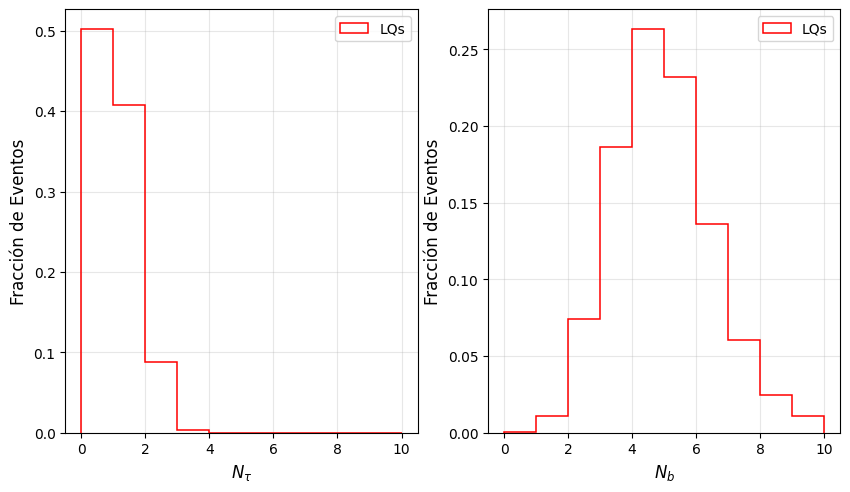

In [18]:
jet_pt = tree["Jet.PT"].array()
jet_eta = tree["Jet.Eta"].array()
jet_phi = tree["Jet.Phi"].array()
jet_mass = tree["Jet.Mass"].array()
jet_btag = tree["Jet.BTag"].array()
jet_tautag = tree["Jet.TauTag"].array()

in_acceptance = (jet_pt > 20) & (abs(jet_eta) < 2.5)

is_tau_hadrónico = in_acceptance & (jet_tautag == 1) & (jet_btag == 0)
is_b_jet = jet_btag == in_acceptance & (jet_tautag == 0) & (jet_btag == 1)

tau_had_pt = jet_pt[is_tau_hadrónico]
tau_had_eta = jet_eta[is_tau_hadrónico]
tau_had_phi = jet_phi[is_tau_hadrónico]
tau_had_mass = jet_mass[is_tau_hadrónico]

bjet_pt = jet_pt[is_b_jet]
bjet_eta = jet_eta[is_b_jet]
bjet_phi = jet_phi[is_b_jet]
bjet_mass = jet_mass[is_b_jet]

elec_pt = tree["Electron.PT"].array()
elec_eta = tree["Electron.Eta"].array()
elec_phi = tree["Electron.Phi"].array()
elec_charge = tree["Electron.Charge"].array()

muon_pt = tree["Muon.PT"].array()
muon_eta = tree["Muon.Eta"].array()
muon_phi = tree["Muon.Phi"].array()
muon_charge = tree["Muon.Charge"].array()

met_met = tree["MissingET.MET"].array()  # Magnitud de la energía faltante
met_phi = tree["MissingET.Phi"].array()

met_pt = ak.flatten(met_met, axis=1)
met_phi = ak.flatten(met_phi, axis=1)

print(f"Total de eventos procesados: {len(met_pt)}")
print(f"Taus hadrónicos en evento 0: {ak.num(tau_had_pt)[0]}")
print(f"b-jets en evento 0:          {ak.num(bjet_pt)[0]}")
print(f"Electrones en evento 0:      {ak.num(elec_pt)[0]}")
print(f"Muones en evento 0:          {ak.num(muon_pt)[0]}")
print(f"MET del evento 0:            {met_pt[0]:.2f} GeV")

Ntaus = ak.num(tau_had_pt)
Nbjets = ak.num(bjet_pt)

bines = np.linspace(0, 10, 11) 
print(bines)
counts1, _ = np.histogram(Ntaus, bins=bines)
counts1norm = counts1 /len(Ntaus)

counts2, _ = np.histogram(Nbjets, bins=bines)
counts2norm = counts2/len(Nbjets)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
axes[0].hist(bines[:-1], bins=bines, weights=counts1norm, 
        histtype='step', color='red', label=r"LQs", linewidth=1.1)
axes[0].set_xlabel(r"$N_{\tau}$", fontsize=12)
axes[0].set_ylabel("Fracción de Eventos", fontsize=12)
#plt.title("Masa Invariante Reconstruida del Higgs ($h \to b\bar{b}$)", fontsize=13)
#plt.axvline(125.0, color="red", linestyle="--", label="Masa Nominal $m_h = 125$ GeV")
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=True)

axes[1].hist(bines[:-1], bins=bines, weights=counts2norm, 
        histtype='step', color='red', label=r"LQs", linewidth=1.1)
axes[1].set_xlabel(r"$N_{b}$", fontsize=12)
axes[1].set_ylabel("Fracción de Eventos", fontsize=12)
#plt.title("Masa Invariante Reconstruida del Higgs ($h \to b\bar{b}$)", fontsize=13)
#plt.axvline(125.0, color="red", linestyle="--", label="Masa Nominal $m_h = 125$ GeV")
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=True)


In [10]:
#Ojo los nombres de los keys dentro de cada zip deben ser esos o análogos predefinidos en el paquete vector
# por ejemplo para el pT puede ser pT,pt o PT, para pseudorepidity eta Eta, para ángulo phi, Phi, para masa mass, Mass,m, M, 
#para energía energy, Energy, e, E, para momentos cartesianos px,py,pz

electron_mass = ak.full_like(tree["Electron.PT"].array(), 0.0005109989)
muon_mass = ak.full_like(tree["Muon.PT"].array(),0.10565837)

electrons = ak.zip(
    {
        "pt": tree["Electron.PT"].array(),
        "eta": tree["Electron.Eta"].array(),
        "phi": tree["Electron.Phi"].array(),
        "mass": electron_mass,
    },
    with_name="Momentum4D",
)
muons = ak.zip(
    {
        "pt": tree["Muon.PT"].array(),
        "eta": tree["Muon.Eta"].array(),
        "phi": tree["Muon.Phi"].array(),
        "mass": muon_mass,  # Masa del muón en GeV
    },
    with_name="Momentum4D",
)
leptons = ak.concatenate(
    [electrons[(electrons.pt > 10) & (abs(electrons.eta) < 2.5)],
     muons[(muons.pt > 10) & (abs(muons.eta) < 2.5)],],
    axis=1,
)
jets = ak.zip(
    {
        "pt": tree["Jet.PT"].array(),
        "eta": tree["Jet.Eta"].array(),
        "phi": tree["Jet.Phi"].array(),
        "mass": tree["Jet.Mass"].array(),
        "btag": tree["Jet.BTag"].array(),
        "tautag": tree["Jet.TauTag"].array(),
    },
    with_name="Momentum4D",
)
pairs = ak.cartesian({"jet": jets, "lepton": leptons}, nested=True)
dr_matrix = pairs.jet.deltaR(pairs.lepton)
jet_overlaps = ak.any(dr_matrix < 0.4, axis=-1)

clean_jets_mask = ~jet_overlaps
clean_jets = jets[clean_jets_mask]

in_acceptance = (clean_jets.pt > 20) & (abs(clean_jets.eta) < 2.5)
is_tau_had = in_acceptance & (clean_jets.tautag == 1) & (clean_jets.btag == 0)
is_b_jet   = in_acceptance & (clean_jets.btag == 1)   & (clean_jets.tautag == 0)

tau_hads = clean_jets[is_tau_had]
b_jets   = clean_jets[is_b_jet]

#imprime para el primer evento
print("Jets totales originales por evento:", ak.num(jets)[0])
print("Jets limpios (post-DR) por evento: ", ak.num(clean_jets)[0])
print("Taus hadrónicos limpios:           ", ak.num(tau_hads)[0])
print("b-jets limpios:                    ", ak.num(b_jets)[0])

#numeros para selección de eventos por ejemplo
num_jets_orig  = ak.num(jets)
num_clean_jets = ak.num(clean_jets)
num_tau_hads   = ak.num(tau_hads)
num_b_jets     = ak.num(b_jets)

topology_mask = (num_b_jets >= 2) & (num_tau_hads >= 2)
num_selected_events = ak.sum(topology_mask)

selected_b_jets   = b_jets[topology_mask]
selected_tau_hads = tau_hads[topology_mask]
selected_met      = met_pt[topology_mask]
selected_leptons  = leptons[topology_mask]

print(f"Eventos iniciales:  {len(b_jets)}")
print(f"Eventos seleccionados: {len(selected_b_jets)}")
print(f"Eficiencia de corte:   {100 * len(selected_b_jets) / len(b_jets):.2f}%")

# Ordena en pT, armando un array con los índices ordenados correctamente
indices_pt = ak.argsort(selected_b_jets.pt, ascending=False, axis=-1)
b_jets_sorted = selected_b_jets[indices_pt]

b1 = b_jets_sorted[:, 0]
b2 = b_jets_sorted[:, 1]

di_bjet_system = b1 + b2
m_bb = di_bjet_system.mass

print("Masa m_bb de los primeros 5 eventos (GeV):")
print(m_bb[:10])

indices_tau_pt = ak.argsort(selected_tau_hads.pt, ascending=False, axis=-1)
tau_hads_sorted = selected_tau_hads[indices_tau_pt]
tau1 = tau_hads_sorted[:, 0]
tau2 = tau_hads_sorted[:, 1]
di_tau_system = tau1 + tau2
m_tautau_vis = di_tau_system.mass
print("Masa visible m_tautau de los primeros 5 eventos (GeV):")
print(m_tautau_vis[:5])

#si queremos calcular todos los pares mbb por ejemplo para seleccionar con algún criterio distinto los eventos:

b_pairs = ak.combinations(selected_b_jets, 2, fields=["b1", "b2"])
di_bjets_all = b_pairs.b1 + b_pairs.b2
m_bb_all = di_bjets_all.mass

delta_m = np.abs(m_bb_all - 125.0)

best_pair_idx = ak.argmin(delta_m, axis=-1, keepdims=True)
m_bb_closest = m_bb_all[best_pair_idx]
m_bb_closest = ak.flatten(m_bb_closest, axis=-1)

print("Masa m_bb más cercana a 125 GeV por evento (GeV):")
print(m_bb_closest[:10])

n_bjets_per_event = ak.num(selected_b_jets)

# 2. Ver cuántos eventos tienen EXACTAMENTE 2 b-jets vs MÁS de 2
n_exact_2 = ak.sum(n_bjets_per_event == 2)
n_more_than_2 = ak.sum(n_bjets_per_event > 2)

print(f"Eventos con exactamente 2 b-jets: {n_exact_2} ({100 * n_exact_2 / len(selected_b_jets):.1f}%)")
print(f"Eventos con 3 o más b-jets:       {n_more_than_2} ({100 * n_more_than_2 / len(selected_b_jets):.1f}%)")
#para extraer los vectores que dan el mejor par y operar luego con ellos

best_b_pairs = b_pairs[best_pair_idx]

best_b1 = ak.flatten(best_b_pairs.b1, axis=-1)
best_b2 = ak.flatten(best_b_pairs.b2, axis=-1)

best_higgs_bb = best_b1 + best_b2

Jets totales originales por evento: 5
Jets limpios (post-DR) por evento:  5
Taus hadrónicos limpios:            1
b-jets limpios:                     1
Eventos iniciales:  10000
Eventos seleccionados: 265
Eficiencia de corte:   2.65%
Masa m_bb de los primeros 5 eventos (GeV):
[121, 135, 124, 149, 111, 46.8, 126, 96.8, 132, 193]
Masa visible m_tautau de los primeros 5 eventos (GeV):
[115, 73.9, 59.2, 82.4, 124]
Masa m_bb más cercana a 125 GeV por evento (GeV):
[121, 135, 124, 149, 111, 46.8, 126, 96.8, 132, 193]
Eventos con exactamente 2 b-jets: 250 (94.3%)
Eventos con 3 o más b-jets:       15 (5.7%)


In [11]:
mask_multi_b = ak.num(selected_b_jets) > 2

m_bb_pt_multi = m_bb[mask_multi_b]
m_bb_closest_multi = m_bb_closest[mask_multi_b]

diff = np.abs(m_bb_pt_multi - m_bb_closest_multi)

print(f"Eventos evaluados: {len(m_bb_pt_multi)}")
print(f"Casos donde los métodos difieren: {ak.sum(diff > 1e-3)}")

Eventos evaluados: 15
Casos donde los métodos difieren: 9


257.0
265
0.9698113207547169
40


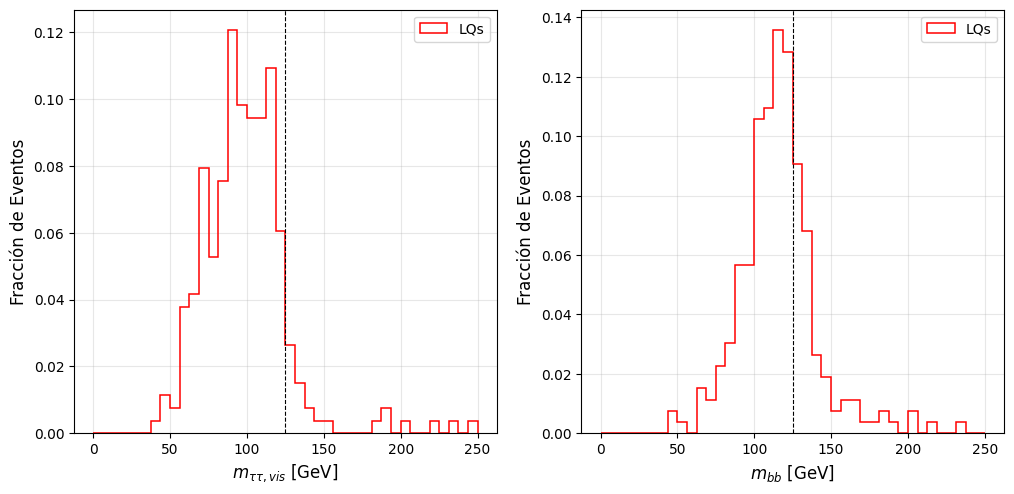

In [26]:
bines = np.linspace(0, 250, 41) 

counts1, _ = np.histogram(m_tautau_vis, bins=bines)
counts1norm = counts1 /len(m_tautau_vis)

counts2, _ = np.histogram(m_bb, bins=bines)
counts2norm = counts2/len(m_bb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].hist(bines[:-1], bins=bines, weights=counts1norm, 
        histtype='step', color='red', label=r"LQs", linewidth=1.1)
axes[0].set_xlabel(r"$m_{\tau\tau , vis}$ [GeV]", fontsize=12)
axes[0].set_ylabel("Fracción de Eventos", fontsize=12)
axes[0].axvline(x=125, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=True)

axes[1].hist(bines[:-1], bins=bines, weights=counts2norm, 
        histtype='step', color='red', label=r"LQs", linewidth=1.1)
axes[1].set_xlabel(r"$m_{bb}$ [GeV]", fontsize=12)
axes[1].set_ylabel("Fracción de Eventos", fontsize=12)
axes[1].axvline(x=125, color='black', linestyle='--', linewidth=0.8)
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=True)


In [27]:
mbbtata = (b1 + b2 + tau1 + tau2).mass
dRtaus = tau1.deltaR(tau2)
dRbb = b1.deltaR(b2)

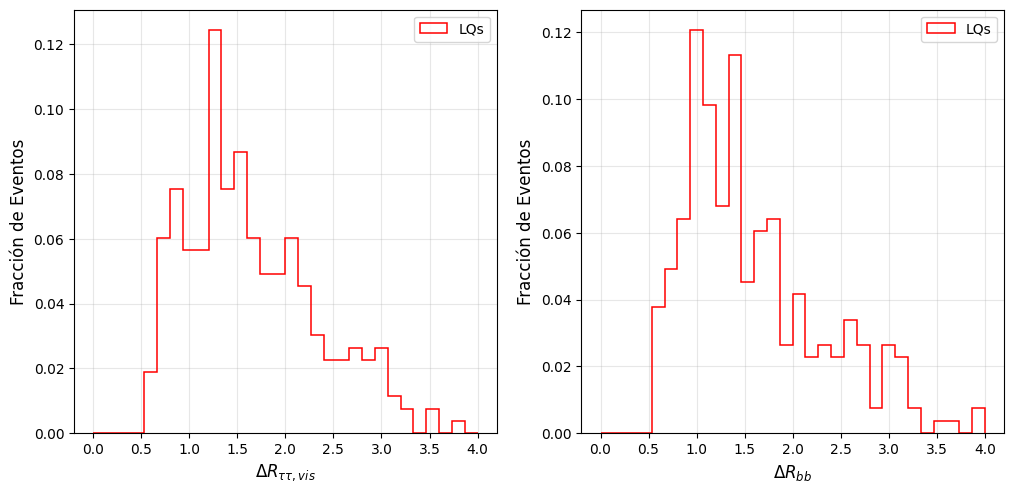

In [28]:
bines = np.linspace(0, 4, 31) 

counts1, _ = np.histogram(dRtaus, bins=bines)
counts1norm = counts1 /len(dRtaus)

counts2, _ = np.histogram(dRbb, bins=bines)
counts2norm = counts2/len(dRbb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].hist(bines[:-1], bins=bines, weights=counts1norm, 
        histtype='step', color='red', label=r"LQs", linewidth=1.1)
axes[0].set_xlabel(r"$\Delta R_{\tau\tau , vis}$", fontsize=12)
axes[0].set_ylabel("Fracción de Eventos", fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=True)

axes[1].hist(bines[:-1], bins=bines, weights=counts2norm, 
        histtype='step', color='red', label=r"LQs", linewidth=1.1)
axes[1].set_xlabel(r"$\Delta R_{bb}$", fontsize=12)
axes[1].set_ylabel("Fracción de Eventos", fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=True)

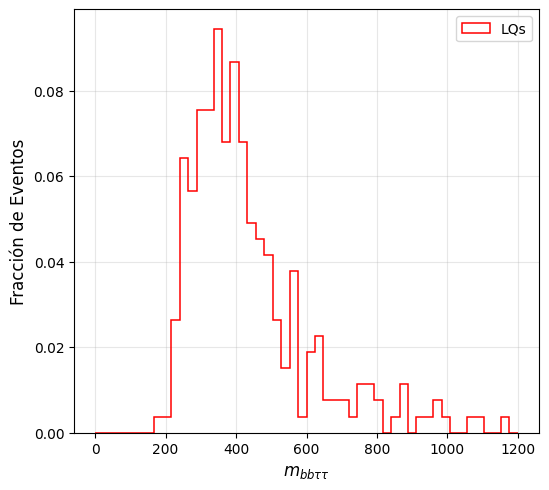

In [31]:
bines = np.linspace(0, 1200, 51) 

counts1, _ = np.histogram(mbbtata, bins=bines)
counts1norm = counts1 /len(mbbtata)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.hist(bines[:-1], bins=bines, weights=counts1norm, 
        histtype='step', color='red', label=r"LQs", linewidth=1.1)
ax.set_xlabel(r"$m_{bb\tau\tau}$", fontsize=12)
ax.set_ylabel("Fracción de Eventos", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(frameon=True)


In [35]:
met_selected=met_pt[topology_mask]

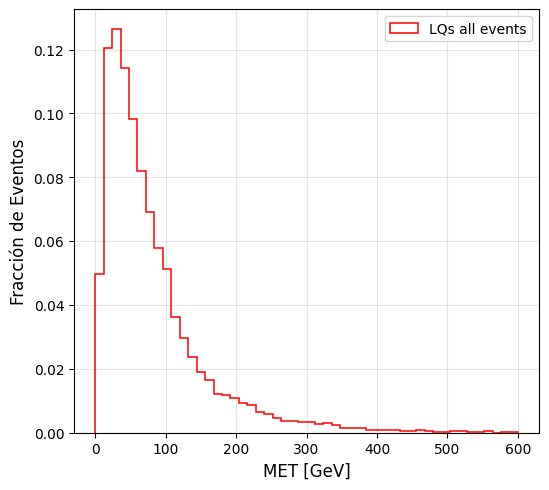

In [49]:
bines = np.linspace(0, 600, 51) 

counts1, _ = np.histogram(met_pt, bins=bines)
counts1norm = counts1 /len(met_pt)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.hist(bines[:-1], bins=bines, weights=counts1norm, 
        histtype='step', color='red', label=r"LQs all events", linewidth=1.1)
ax.set_xlabel(r"MET [GeV]", fontsize=12)
ax.set_ylabel("Fracción de Eventos", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(frameon=True)


0.1811320754716981


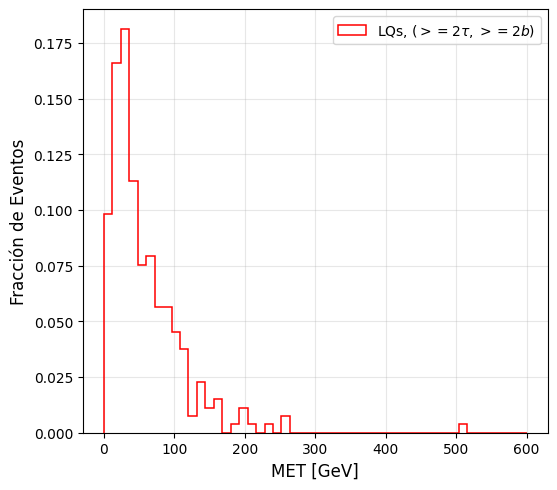

In [50]:
bines = np.linspace(0, 600, 51) 

counts1, _ = np.histogram(met_selected, bins=bines)
counts1norm = counts1 /len(met_selected)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.hist(bines[:-1], bins=bines, weights=counts1norm, 
        histtype='step', color='red', label=r"LQs, ($>=2\tau$, $>=2b$)", linewidth=1.1)
ax.set_xlabel(r"MET [GeV]", fontsize=12)
ax.set_ylabel("Fracción de Eventos", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(frameon=True)

print(max(counts1norm))
